# Práctica: series de tiempo y predicción con seis variables


**Pregunta central:** ¿cómo estiman una regresión lineal y una red neuronal la esperanza de vida cuando reciben información de población, nacimientos, defunciones, defunciones de menores de cinco años, salud y economía?

Usaremos el dataset integrado en clase, con llave `entity`, `year`, y objetivo `life_expectancy`. Primero observaremos cómo cambian las variables a través del tiempo; después pasaremos de una a seis variables predictoras y compararemos los resultados de dos modelos.

**Esta es una práctica introductoria:** La evaluación formal, separación para evaluación y selección de modelos se estudiarán en la siguiente práctica. Las estimaciones históricas de esta práctica se obtienen sobre datos usados para entrenar: muestran funcionamiento, no demuestran desempeño futuro.



## Objetivos y recorrido
1. Reconocer una serie de tiempo y distinguirla de una tabla con múltiples entidades.
2. Observar tendencia y cambios anuales de la esperanza de vida.
3. Identificar seis variables predictoras y una variable objetivo.
4. Entrenar una regresión lineal múltiple y una red neuronal sencilla.
5. Comparar sus estimaciones de forma descriptiva.
6. Distinguir estimación histórica, pronóstico temporal y escenario condicionado.

**Lo que cambia respecto de la práctica anterior:** antes una sola variable entraba a cada modelo. Ahora seis valores entran juntos para producir una sola salida. La regresión lineal sirve como puente conocido hacia la red neuronal.

## 1. Preparar el entorno
asegurate de tener tu `dataset_7variables_2000_2022.csv` en `data/raw/`. Selecciona en VS Code el kernel de tu `.venv`.

Si faltan paquetes, instala desde la terminal con el entorno activado:
```bash
python -m pip install pandas numpy matplotlib scikit-learn ipykernel
```
La práctica no requiere nuevas librerias.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})
print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.2
pandas: 3.0.6 numpy: 2.5.3
scikit-learn: 1.9.1


In [2]:
nombre_csv = "dataset_7variables_2000_2022.csv"

rutas = [Path("data/raw") / nombre_csv, Path("../data/raw") / nombre_csv]


ruta_csv = next((ruta for ruta in rutas if ruta.exists()), None)
print (ruta_csv)

if ruta_csv is None:
    raise FileNotFoundError("Coloca el CSV en data/raw/.")

df = pd.read_csv(ruta_csv)

df = df.sort_values(["entity", "year"])

print("Filas y columnas:", df.shape)

print(df.head())

data\raw\dataset_7variables_2000_2022.csv
Filas y columnas: (4244, 9)
        entity  year  population     births    deaths  child_deaths_under_5  \
0  Afghanistan  2002  21378123.0  1015202.0  239161.0                123215   
1  Afghanistan  2003  22733053.0  1069727.0  243573.0                123894   
2  Afghanistan  2004  23560656.0  1095372.0  244435.0                122315   
3  Afghanistan  2005  24404575.0  1097038.0  241932.0                118420   
4  Afghanistan  2006  25424100.0  1120880.0  245586.0                116622   

   health_percentage        gdp  life_expectancy  
0           9.443391  1774.3087          56.2251  
1           8.941258  1815.9282          57.1713  
2           9.808474  1776.9182          57.8098  
3           9.948289  1908.1147          58.2468  
4          10.622766  1929.7239          58.5533  


## 2. Identificar las columnas
| Campo | Papel en esta práctica |
|---|---|
| `entity`, `year` | Llave; entidad y año del registro |
| `code` | Identificador adicional |
| `population` | Predictora 1: población |
| `births` | Predictora 2: nacimientos |
| `deaths` | Predictora 3: defunciones |
| `child_deaths_under_5` | Predictora 4: defunciones de menores de 5 años |
| `percentage_health` | Predictora 5: indicador porcentual de salud |
| `gdp` | Predictora 6: indicador económico |
| `life_expectancy` | Variable objetivo: esperanza de vida, en años |

El archivo contiene siete variables medidas, incluyendo el objetivo, más tres campos de identificación. `year` se utiliza para ordenar y graficar; en estos modelos **no será una séptima variable predictora**.

Consulta los metadatos originales de OWID antes de interpretar las unidades de `gdp` o la base del porcentaje de `percentage_health`. Aquí usamos los valores tal como aparecen en el CSV; sus nombres no bastan para confirmar su definición exacta.

In [3]:
predictoras = ["population", "births", "deaths", "child_deaths_under_5", "percentage_health", "gdp"]

objetivo = "life_expectancy"

print("Entidades:", df["entity"].nunique())

print("Primer año:", df["year"].min(), "Último año:", df["year"].max())

display(df.groupby("entity")["year"].agg(["min", "max", "count"]).head(10))

Entidades: 187
Primer año: 2000 Último año: 2022


,min,max,count
entity,,,
Afghanistan,2002,2022,21
Albania,2000,2022,23
Algeria,2000,2022,23
Andorra,2000,2022,23
Angola,2000,2022,23
Antigua and Barbuda,2000,2022,23
Argentina,2000,2022,23
Armenia,2000,2022,23
Australia,2000,2021,22


## 3. Tema 4.4: ¿qué es una serie de tiempo?
Una serie de tiempo es una secuencia de observaciones ordenadas por tiempo. 

Si seleccionamos México y `life_expectancy`, tendremos una serie anual de esperanza de vida.

Nuestro dataset completo es un **panel de entidades y años**: contiene varias series, una por entidad para cada indicador. No debemos unir el último año de un país con el primero de otro como si fueran una sola serie.

- **Frecuencia:** cada cuánto se registra un valor; aquí es anual.
- **Tendencia:** dirección de cambio a lo largo del tiempo.
- **Variación anual:** diferencia entre un año y el anterior.
- **Cambio abrupto:** variación que rompe el comportamiento previo.
- **Horizonte de pronóstico:** cuántos periodos hacia adelante se quiere estimar.

Con datos anuales no podemos observar patrones mensuales. Una fluctuación no demuestra por sí sola estacionalidad.

,entity,year,population,births,deaths,child_deaths_under_5,health_percentage,gdp,life_expectancy
2439,Mexico,2000,98625553.0,2385977.0,540567.0,66928,4.244365,20470.494,72.5621
2440,Mexico,2001,100099101.0,2380261.0,543803.0,64012,4.582014,20078.219,72.9118
2441,Mexico,2002,101548627.0,2374140.0,553391.0,61210,4.830428,19744.793,73.1056
2442,Mexico,2003,102978517.0,2351177.0,563140.0,58280,5.539788,19701.463,73.3080
2443,Mexico,2004,104394131.0,2335226.0,575925.0,55625,5.683502,20127.225,73.4324
2444,Mexico,2005,105811504.0,2318498.0,585859.0,53204,5.581101,20277.256,73.6267
2445,Mexico,2006,107253666.0,2303997.0,597892.0,50857,5.406479,20965.826,73.7457
2446,Mexico,2007,108774356.0,2296268.0,611318.0,48847,5.506680,21102.270,73.7955
2447,Mexico,2008,110374286.0,2297950.0,627177.0,47137,5.445874,20992.560,73.6949
2448,Mexico,2009,111999720.0,2303532.0,642292.0,45610,5.847865,19385.543,73.6281


,year,life_expectancy
2439,2000,72.5621
2440,2001,72.9118
2441,2002,73.1056
2442,2003,73.3080
2443,2004,73.4324
2444,2005,73.6267
2445,2006,73.7457
2446,2007,73.7955
2447,2008,73.6949
2448,2009,73.6281


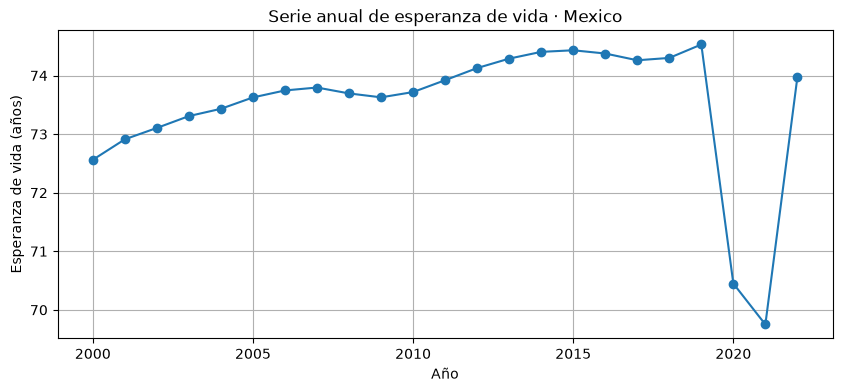

In [4]:
pais = "Mexico"
datos_pais = df.loc[df["entity"] == pais].copy()

datos_pais = datos_pais.sort_values("year")
display(datos_pais)

assert not datos_pais.empty, "La entidad no está en el archivo."

serie_vida = datos_pais[["year", objetivo]].copy()

display(serie_vida.head(10))

plt.plot(serie_vida["year"], serie_vida[objetivo], marker="o")
plt.title(f"Serie anual de esperanza de vida · {pais}")
plt.xlabel("Año"); plt.ylabel("Esperanza de vida (años)"); plt.show()

### Observar cambios y suavizar la serie
`diff()` resta el valor del año anterior al actual. El primer cambio es nulo porque no hay un dato previo.

Una media móvil de tres años promedia el año actual y sus dos anteriores. Ayuda a observar el comportamiento general; esta línea suavizada no es automáticamente un pronóstico.

,year,life_expectancy,cambio_anual,media_movil_3
2454,2015,74.432,0.027,74.375
2455,2016,74.376,-0.055,74.404
2456,2017,74.261,-0.115,74.356
2457,2018,74.301,0.040,74.313
2458,2019,74.530,0.229,74.364
2459,2020,70.449,-4.081,73.093
2460,2021,69.750,-0.699,71.576
2461,2022,73.973,4.223,71.391


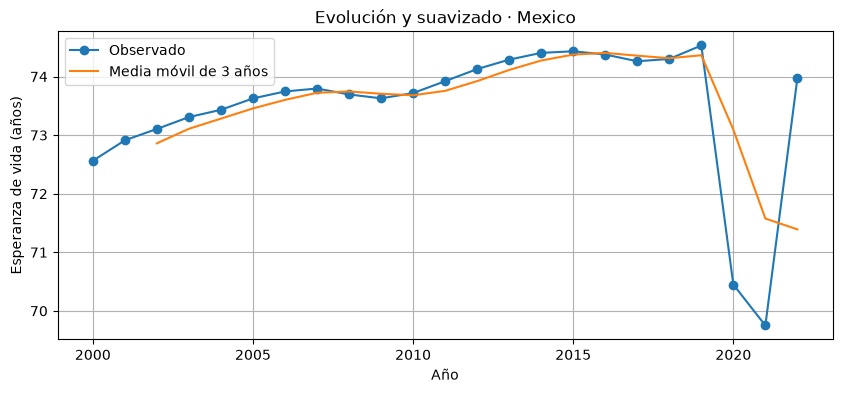

In [5]:
serie_vida["cambio_anual"] = serie_vida[objetivo].diff()
serie_vida["media_movil_3"] = serie_vida[objetivo].rolling(3).mean()
display(serie_vida.tail(8).round(3))
plt.plot(serie_vida["year"], serie_vida[objetivo], "o-", label="Observado")
plt.plot(serie_vida["year"], serie_vida["media_movil_3"], label="Media móvil de 3 años")
plt.xlabel("Año"); plt.ylabel("Esperanza de vida (años)")
plt.title(f"Evolución y suavizado · {pais}"); plt.legend(); plt.show()

**Para comentar:** ¿la esperanza de vida aumenta todos los años? ¿Dónde aparece un cambio fuerte? ¿Qué información adicional necesitaríamos para explicar su causa?

Las gráficas muestran qué cambió; no por qué ocurrió.

KeyError: 'percentage_health'

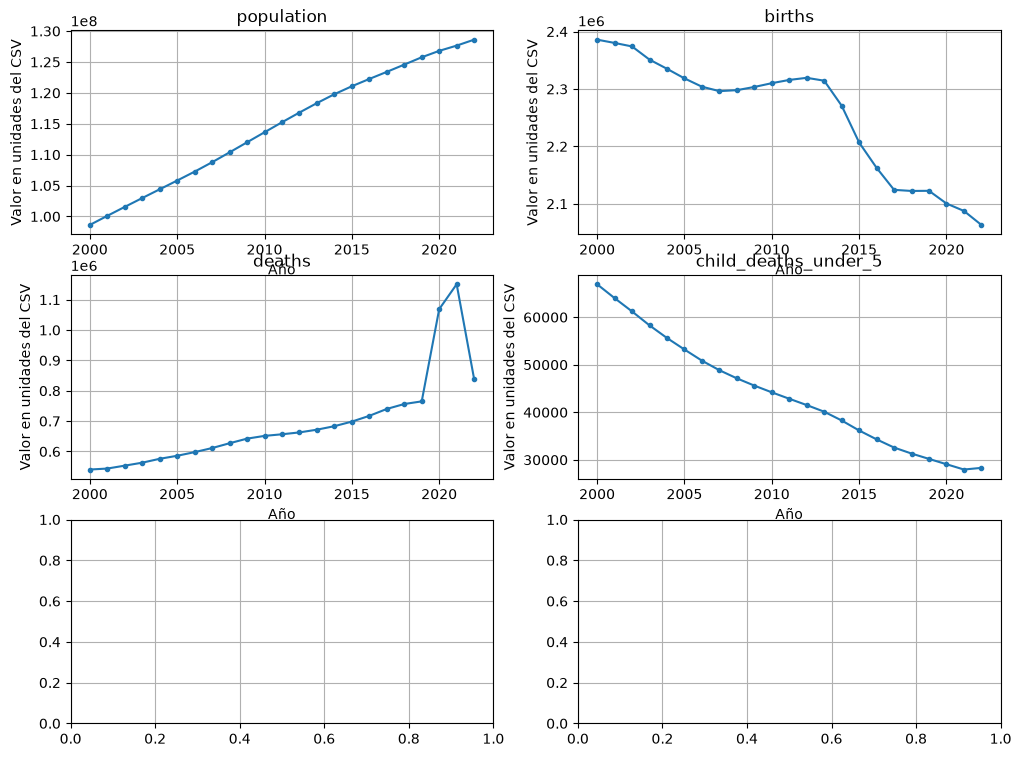

In [6]:
fig, ejes = plt.subplots(3, 2, figsize=(12, 9))
for columna, eje in zip(predictoras, ejes.ravel()):
    eje.plot(datos_pais["year"], datos_pais[columna], marker=".")
    eje.set_title(columna)
    eje.set_xlabel("Año")
    eje.set_ylabel("Valor en unidades del CSV")
fig.suptitle(f"Seis series de variables predictoras · {pais}")
plt.tight_layout(); plt.show()

### Un primer pronóstico temporal sencillo
Para introducir el concepto de pronóstico, usaremos **persistencia**: repetir el último valor conocido de la serie. Desde 2022, el horizonte de un año corresponde a 2023.

Este ejemplo usa únicamente el historial de `life_expectancy`. No es la regresión múltiple ni la red neuronal. Sirve para entender qué significa pasar del dato observado a una hipótesis sobre el futuro.

In [ ]:
ultimo_anio = int(serie_vida["year"].iloc[-1])
ultimo_valor = float(serie_vida[objetivo].iloc[-1])
pronostico_persistencia = pd.DataFrame({
    "year": [ultimo_anio + 1], "life_expectancy_pronosticada": [ultimo_valor],
    "supuesto": ["Repetir el último valor conocido"]
})
display(pronostico_persistencia)

,year,life_expectancy_pronosticada,supuesto
0,2023,73.9731,Repetir el último valor conocido


## 4. Pasar de una a seis variables predictoras
En cada fila, las seis predictoras y el objetivo corresponden a la **misma entidad y al mismo año**. El modelo aprenderá una relación contemporánea:

`life_expectancy = f(population, births, deaths, child_deaths_under_5, percentage_health, gdp)`

Para un registro de México en 2018, entran sus seis indicadores de 2018 y la salida buscada es su esperanza de vida de 2018.

Esta formulación estima esperanza de vida **dadas esas condiciones**; todavía no aprende cómo cambian esas condiciones entre años. Ordenar por `year` no convierte automáticamente una red densa en un modelo de pronóstico temporal.

Entrenaremos con todas las entidades para disponer de miles de ejemplos. Los 23 registros de México sirven para visualizar, pero son pocos para ajustar por sí solos una red. `entity` y `code` no entran al modelo: esta versión aprende una relación común y no representa explícitamente diferencias entre países.

In [ ]:
X = df[predictoras].copy()
y = df[objetivo].copy()

print("X: filas de ejemplos y seis columnas de entrada", X.shape)
print("y: un objetivo por ejemplo", y.shape)

display(X.head())
display(y.head())

print("Ejemplo de una entidad y año:")
display(datos_pais.loc[datos_pais["year"] == 2018, ["entity", "year"] + predictoras + [objetivo]])

X: filas de ejemplos y seis columnas de entrada (4244, 6)
y: un objetivo por ejemplo (4244,)


,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,21378123.0,1015202.0,239161.0,123215,9.443391,1774.3087
1,22733053.0,1069727.0,243573.0,123894,8.941258,1815.9282
2,23560656.0,1095372.0,244435.0,122315,9.808474,1776.9182
3,24404575.0,1097038.0,241932.0,118420,9.948289,1908.1147
4,25424100.0,1120880.0,245586.0,116622,10.622766,1929.7239


0    56.2251
1    57.1713
2    57.8098
3    58.2468
4    58.5533
Name: life_expectancy, dtype: float64

Ejemplo de una entidad y año:


,entity,year,population,births,deaths,child_deaths_under_5,percentage_health,gdp,life_expectancy
18,Mexico,2018,124573713.0,2122316.0,756310.0,31321,5.238214,21997.773,74.3009


## 5. Escalar los valores
Población y nacimientos pueden tener valores enormes, mientras que el indicador de salud tiene otra escala. Para facilitar el entrenamiento de la red, estandarizamos las seis columnas.

`StandardScaler` calcula por columna `(valor − media) / desviación estándar`. No cambia qué variable representa cada columna. Tampoco convierte conteos en tasas ni elimina el efecto del tamaño de los países.

Usaremos las mismas entradas escaladas en ambos modelos. También escalaremos el objetivo para la red y recuperaremos después sus unidades originales.

En esta introducción todos los datos se usan para el ajuste. Cuando estudiemos evaluación, los escaladores se ajustarán solamente con el subconjunto de entrenamiento.

In [ ]:
escalador_X = StandardScaler()
X_escalado = escalador_X.fit_transform(X)

escalador_y = StandardScaler()
y_escalado = escalador_y.fit_transform(y.to_numpy().reshape(-1, 1)).ravel()

display(pd.DataFrame(X_escalado, columns=predictoras).head().round(3))
print("Primeros objetivos escalados:", y_escalado[:5].round(3))

,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,-0.102,-0.046,-0.085,0.081,1.147,-0.848
1,-0.099,-0.041,-0.084,0.082,0.969,-0.846
2,-0.098,-0.038,-0.084,0.079,1.276,-0.848
3,-0.096,-0.038,-0.085,0.072,1.325,-0.842
4,-0.094,-0.036,-0.084,0.069,1.564,-0.841


Primeros objetivos escalados: [-1.588 -1.479 -1.406 -1.356 -1.321]


## 6. Puente: regresión lineal múltiple
Es el mismo tipo de modelo que ya conocemos, ahora con seis entradas:

`ŷ = b0 + b1·x1 + b2·x2 + b3·x3 + b4·x4 + b5·x5 + b6·x6`

`fit(X, y)` ajusta los coeficientes a partir de los ejemplos. `predict(X)` utiliza los coeficientes aprendidos para producir estimaciones.

La regresión recibe el objetivo en años, por lo que su salida ya tiene esa unidad.

In [ ]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_escalado, y)
estimaciones_lineales = modelo_lineal.predict(X_escalado)
print("Modelo lineal entrenado con seis variables.")

Modelo lineal entrenado con seis variables.


## 7. Tema 4.5: introducir una red neuronal artificial
Usaremos `MLPRegressor`, un perceptrón multicapa para regresión.

| Parte | Configuración |
|---|---|
| Entrada | Seis números, uno por variable predictora |
| Primera capa oculta | 16 neuronas |
| Segunda capa oculta | 8 neuronas |
| Salida | Una estimación de esperanza de vida |

Cada neurona combina valores con **pesos** y un **sesgo**. En las capas ocultas usamos ReLU, `max(0, z)`, para permitir relaciones no lineales. La salida de regresión es lineal.

Durante `fit`, la red genera estimaciones, calcula una pérdida y ajusta los pesos. La retropropagación calcula gradientes; Adam los utiliza para actualizar los parámetros.

- `hidden_layer_sizes=(16, 8)`: estructura de las capas ocultas.
- `max_iter=2000`: máximo de épocas de entrenamiento, no de años proyectados.
- `random_state=42`: fija la semilla para hacer el ejercicio reproducible.
- `alpha=0.01`: regularización de los pesos.

Esta es una red densa, no una LSTM. La arquitectura es una elección didáctica; todavía no se ha seleccionado mediante evaluación. No necesita TensorFlow.

In [ ]:
modelo_red = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    alpha=0.01,
    max_iter=2000,
    random_state=42
)
modelo_red.fit(X_escalado, y_escalado)
print("Red neuronal entrenada.")
print("Épocas realizadas:", modelo_red.n_iter_)
print("Matrices de pesos:", [matriz.shape for matriz in modelo_red.coefs_])

Red neuronal entrenada.
Épocas realizadas: 428
Matrices de pesos: [(6, 16), (16, 8), (8, 1)]


Las matrices de pesos conectan 6→16, 16→8 y 8→1. La red no guarda una predicción por cada año futuro; guarda parámetros que transforman seis entradas en una salida.

Si aparece `ConvergenceWarning`, alcanzó el límite de entrenamiento sin cumplir su criterio de parada. Se debe revisar el entrenamiento antes de interpretar resultados.

In [ ]:
estimaciones_red_escaladas = modelo_red.predict(X_escalado)
estimaciones_red = escalador_y.inverse_transform(
    estimaciones_red_escaladas.reshape(-1, 1)
).ravel()
print("Primeras estimaciones de la red, en años:", estimaciones_red[:5].round(3))

Primeras estimaciones de la red, en años: [54.64  55.356 55.576 56.005 55.737]


## 8. Comparar las estimaciones de forma descriptiva
Tomamos los registros históricos de México para ver qué produce cada modelo. Ambos fueron entrenados usando estas filas y las de las demás entidades.

Podemos observar diferencias de forma y valores. Esta comparación no es una evaluación independiente y no permite concluir qué modelo funcionará mejor en datos futuros. Dejamos MAE, RMSE, prueba y validación para la siguiente práctica.

,entity,year,life_expectancy,estimacion_lineal,estimacion_red
2454,Mexico,2015,74.432,70.711,75.520
2455,Mexico,2016,74.376,70.684,75.460
2456,Mexico,2017,74.261,70.677,75.449
2457,Mexico,2018,74.301,70.678,75.493
2458,Mexico,2019,74.530,70.656,75.621
2459,Mexico,2020,70.449,69.357,73.376
2460,Mexico,2021,69.750,69.222,72.866
2461,Mexico,2022,73.973,70.649,75.691


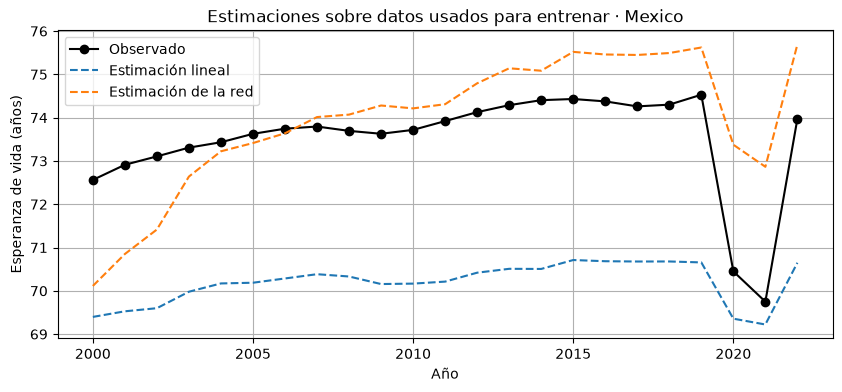

In [ ]:
comparacion = df[["entity", "year", objetivo]].copy()
comparacion["estimacion_lineal"] = estimaciones_lineales
comparacion["estimacion_red"] = estimaciones_red
comparacion_pais = comparacion.loc[comparacion["entity"] == pais].copy()
display(comparacion_pais.tail(8).round(3))
plt.plot(comparacion_pais["year"], comparacion_pais[objetivo], "o-", color="black", label="Observado")
plt.plot(comparacion_pais["year"], comparacion_pais["estimacion_lineal"], "--", label="Estimación lineal")
plt.plot(comparacion_pais["year"], comparacion_pais["estimacion_red"], "--", label="Estimación de la red")
plt.title(f"Estimaciones sobre datos usados para entrenar · {pais}")
plt.xlabel("Año"); plt.ylabel("Esperanza de vida (años)"); plt.legend(); plt.show()

## 9. ¿Podemos proyectar después de 2022?
Sí, pero estos dos modelos requieren **las seis entradas correspondientes al año que queremos estimar**. Para 2023 necesitaríamos población, nacimientos, defunciones, defunciones de menores de 5 años, indicador de salud y `gdp` de 2023.

Hay dos caminos para una práctica posterior:
1. Pronosticar cada predictora con su propia serie de tiempo y alimentar el modelo con esas proyecciones.
2. Declarar escenarios con valores supuestos para las predictoras.

Hoy haremos un ejemplo corto del segundo camino. No estamos prediciendo automáticamente el paso del tiempo; preguntamos: **¿qué esperanza de vida estima el modelo si se presentan estas condiciones?**

Para que quede claro, construiremos dos escenarios hipotéticos de 2023 desde los valores de México en 2022:
- **Constante:** las seis variables conservan el valor de 2022.
- **Cambio de indicadores:** defunciones y defunciones de menores de 5 bajan 5%; salud y `gdp` suben 5%; población y nacimientos permanecen iguales.

Los cambios son relativos: aumentar 5% un indicador de 10 da 10.5, no 15. Son supuestos didácticos y simplificados, no proyecciones demográficas coherentes ni políticas cuyo efecto causal hayamos demostrado.

In [ ]:
base_2022 = datos_pais.loc[datos_pais["year"] == 2022, predictoras].copy()
base_2022 = base_2022.reset_index(drop=True)

escenario_constante = base_2022.copy()
escenario_cambio = base_2022.copy()
escenario_cambio["deaths"] = escenario_cambio["deaths"] * 0.95
escenario_cambio["child_deaths_under_5"] = escenario_cambio["child_deaths_under_5"] * 0.95
escenario_cambio["percentage_health"] = escenario_cambio["percentage_health"] * 1.05
escenario_cambio["gdp"] = escenario_cambio["gdp"] * 1.05

entradas_escenarios = pd.concat([escenario_constante, escenario_cambio], ignore_index=True)
escenarios = pd.DataFrame({"entity": [pais, pais], "year": [2023, 2023],
    "escenario": ["Constante", "Cambio de indicadores"]})
display(pd.concat([escenarios, entradas_escenarios], axis=1))

,entity,year,escenario,population,births,deaths,child_deaths_under_5,percentage_health,gdp
0,Mexico,2023,Constante,128613116.0,2063075.0,838627.00,28309.00,5.709197,21391.85700
1,Mexico,2023,Cambio de indicadores,128613116.0,2063075.0,796695.65,26893.55,5.994657,22461.44985


In [ ]:
entradas_escenarios_escaladas = escalador_X.transform(entradas_escenarios[predictoras])
escenarios["estimacion_lineal"] = modelo_lineal.predict(entradas_escenarios_escaladas)
pred_red_escenarios = modelo_red.predict(entradas_escenarios_escaladas)
escenarios["estimacion_red"] = escalador_y.inverse_transform(
    pred_red_escenarios.reshape(-1, 1)
).ravel()
display(escenarios.round(3))

# Con las mismas entradas, el escenario constante debe dar la misma
# estimación que el modelo dio al registro de 2022.
registro_2022 = comparacion_pais.loc[comparacion_pais["year"] == 2022].iloc[0]
assert np.isclose(escenarios.loc[0, "estimacion_red"], registro_2022["estimacion_red"])
assert np.isclose(escenarios.loc[0, "estimacion_lineal"], registro_2022["estimacion_lineal"])
print("Mismas seis entradas → misma estimación, aunque cambiemos la etiqueta del año.")

,entity,year,escenario,estimacion_lineal,estimacion_red
0,Mexico,2023,Constante,70.649,75.691
1,Mexico,2023,Cambio de indicadores,71.217,76.925


Mismas seis entradas → misma estimación, aunque cambiemos la etiqueta del año.


**Interpreta el resultado:**
- El escenario constante repite la **estimación** del registro de 2022, no necesariamente su esperanza de vida observada. El modelo tiene error de ajuste.
- Cambiar solamente `year` de 2023 a 2024 o 2100 no cambia la salida: el año no entra al modelo.
- El escenario de cambio puede producir una respuesta distinta a la intuición. No hay garantía de que más `gdp` o un cambio en salud genere una mejora: el modelo aprende asociaciones, no efectos causales.
- Los conteos absolutos dependen del tamaño de la población; normalizarlos mediante tasas será una extensión posterior.

**¿Dónde entra el otro dataset de OWID?** En una etapa posterior podemos graficar sus observaciones y proyecciones de `life_expectancy` junto a nuestras curvas, una vez que tengamos escenarios o proyecciones para las seis entradas. Las proyecciones de OWID serán una referencia externa, no observaciones futuras para medir error. Primero revisaremos metadatos, país, definición del indicador y separación entre históricos y proyecciones.

No extrapolaremos hasta 2100 en esta introducción: primero debemos construir las entradas futuras y estudiar cómo evaluar los modelos.

## 10. Actividades y entregable
1. Define serie de tiempo e identifica frecuencia, entidad y variable en la gráfica de México.
2. Describe un cambio visible en la esperanza de vida y en dos variables predictoras, sin atribuirles una relación causal.
3. Muestra las seis entradas y la salida de un registro específico. Explica por qué `X` tiene seis columnas y `y` una sola variable.
4. Explica qué hacen `fit`, `predict`, `transform` e `inverse_transform` en esta práctica.
5. Describe una diferencia visible entre las estimaciones lineales y las de la red. Explica por qué aún no podemos declarar un modelo ganador.
6. Cambia **una sola variable** del escenario, por ejemplo `gdp`, y observa cómo responde cada modelo. Registra el valor supuesto, la salida y una limitación de la interpretación.
7. Explica por qué un dataset que solo contiene proyecciones de `life_expectancy` no proporciona las seis entradas futuras que necesitan estos modelos.

**Entregable:** notebook ejecutado, gráfica de la serie histórica, gráfica descriptiva de los dos modelos, tabla de escenarios y una conclusión breve sobre qué aprendiste y qué falta para producir pronósticos futuros.

**Siguiente etapa:** evaluar modelos con separación temporal y, después, construir trayectorias para las predictoras y compararlas con las proyecciones de OWID.

### Referencias
- Datos: CSV construido en clase con fuentes de Our World in Data; conservar los metadatos originales de cada variable.
- [scikit-learn: regresión lineal](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
- [scikit-learn: redes neuronales supervisadas](https://scikit-learn.org/stable/modules/neural_networks_supervised.html).
- [scikit-learn: MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html).
- [scikit-learn: StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

**Alcance:** introducción a series temporales y su relación con pronósticos (4.4); construcción de una red neuronal y estimaciones bajo escenarios (4.5).

## 11. Distinción entre históricos y proyecciones de OWID
Esta sección revisa un dataset que contiene dos columnas: estimaciones históricas **1950–2023** y proyecciones del escenario medio **2024–2100**. Es importante distinguir el fin de nuestro dataset integrado (2022) del fin del histórico de esta otra fuente (2023).

La esperanza de vida al nacer es un indicador de periodo: resume las tasas de mortalidad del año. No es un seguimiento de una generación real hasta que fallezca.

Usaremos un nombre distinto, `referencia_owid`, para conservar nuestro `df` original. No entrenaremos la red con las proyecciones de OWID.

In [ ]:
url_base_owid = "https://ourworldindata.org/grapher/life-expectancy-at-birth-including-the-un-projections"
parametros_owid = "?v=1&csvType=full&useColumnShortNames=true"
referencia_owid = pd.read_csv(
    url_base_owid + ".csv" + parametros_owid,
    storage_options={"User-Agent": "Our World In Data data fetch/1.0"}
)
print("Columnas recibidas:")
print(referencia_owid.columns.tolist())
display(referencia_owid.head())

Columnas recibidas:
['entity', 'code', 'year', 'life_expectancy__sex_all__age_0__variant_estimates', 'life_expectancy__sex_all__age_0__variant_medium__projected']


,entity,code,year,life_expectancy__sex_all__age_0__variant_estimates,life_expectancy__sex_all__age_0__variant_medium__projected
0,Afghanistan,AFG,1950,28.156,NaN
1,Afghanistan,AFG,1951,28.584,NaN
2,Afghanistan,AFG,1952,29.014,NaN
3,Afghanistan,AFG,1953,29.452,NaN
4,Afghanistan,AFG,1954,29.698,NaN


### Leer los metadatos
Utilizamos `urllib.request` y `json`, incluidos en Python, para no instalar otro paquete. Esta celda cumple el mismo propósito que `requests.get(...).json()`.

El nombre de la columna proyectada del CSV termina en `__projected`, mientras que su clave en los metadatos de esta descarga no lleva ese sufijo. Los mostramos por separado para evitar confundirlos.

In [ ]:
import json
from urllib.request import Request, urlopen

solicitud_metadata = Request(
    url_base_owid + ".metadata.json" + parametros_owid,
    headers={"User-Agent": "Our World In Data data fetch/1.0"}
)
with urlopen(solicitud_metadata, timeout=30) as respuesta_metadata:
    metadata_owid = json.load(respuesta_metadata)
print("Claves de metadatos:", list(metadata_owid["columns"]))
col_hist = "life_expectancy__sex_all__age_0__variant_estimates"
col_proy = "life_expectancy__sex_all__age_0__variant_medium__projected"
assert {"entity", "year", col_hist, col_proy}.issubset(referencia_owid.columns), "Revisar las columnas de la nueva descarga."
print("Fuente:", metadata_owid["columns"][col_hist].get("citationShort"))
print("Unidad:", metadata_owid["columns"][col_hist].get("unit"))
print("Descripción:", metadata_owid["columns"][col_hist].get("descriptionShort"))

Claves de metadatos: ['life_expectancy__sex_all__age_0__variant_estimates', 'life_expectancy__sex_all__age_0__variant_medium']
Fuente: UN, World Population Prospects (2024) – processed by Our World in Data
Unidad: years
Descripción: Period life expectancy at birth.


In [ ]:
referencia_pais = referencia_owid.loc[
    referencia_owid["entity"] == pais, ["entity", "year", col_hist, col_proy]
].copy().sort_values("year")
assert not referencia_pais.empty, "La entidad no está en esta fuente."

historico_owid = referencia_pais.loc[referencia_pais[col_hist].notna(), ["year", col_hist]].copy()
proyeccion_owid = referencia_pais.loc[referencia_pais[col_proy].notna(), ["year", col_proy]].copy()
historico_owid = historico_owid.rename(columns={col_hist: "life_expectancy_owid"})
proyeccion_owid = proyeccion_owid.rename(columns={col_proy: "life_expectancy_owid"})
print("Histórico:", historico_owid["year"].min(), "a", historico_owid["year"].max())
print("Proyección:", proyeccion_owid["year"].min(), "a", proyeccion_owid["year"].max())
display(referencia_pais.loc[referencia_pais["year"].between(2022, 2025)])

Histórico: 1950 a 2023
Proyección: 2024 a 2100


,entity,year,life_expectancy__sex_all__age_0__variant_estimates,life_expectancy__sex_all__age_0__variant_medium__projected
22118,Mexico,2022,73.973,NaN
22119,Mexico,2023,75.069,NaN
22120,Mexico,2024,NaN,75.264
22121,Mexico,2025,NaN,75.446



Los periodos se calculan con los datos descargados para poder detectar cambios futuros de la fuente.

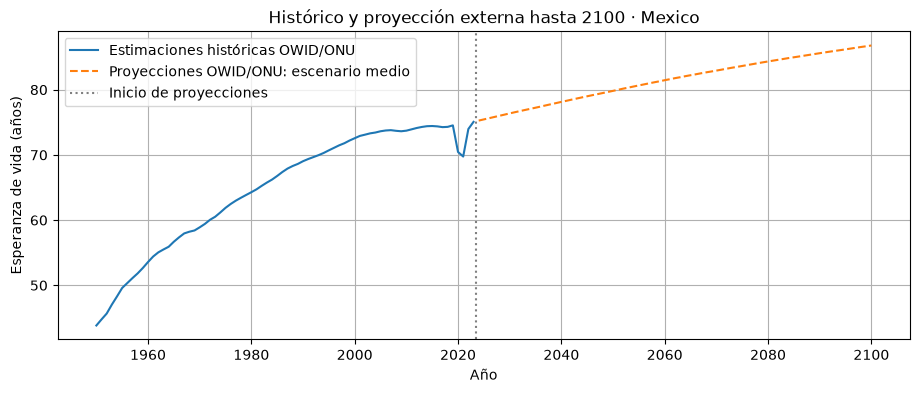

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(historico_owid["year"], historico_owid["life_expectancy_owid"], label="Estimaciones históricas OWID/ONU")
plt.plot(proyeccion_owid["year"], proyeccion_owid["life_expectancy_owid"], "--", label="Proyecciones OWID/ONU: escenario medio")
inicio_proyecciones = int(proyeccion_owid["year"].min())
plt.axvline(inicio_proyecciones - 0.5, color="gray", linestyle=":", label="Inicio de proyecciones")
plt.xlabel("Año"); plt.ylabel("Esperanza de vida (años)")
plt.title(f"Histórico y proyección externa hasta 2100 · {pais}")
plt.legend(); plt.show()

### Situar nuestros escenarios en una ventana corta
Mostramos 2000–2030 y los dos puntos de nuestros escenarios de 2023. Esos puntos son estimaciones bajo supuestos desde nuestro dataset hasta 2022. La fuente externa ya incluye una estimación histórica para 2023; sus proyecciones comienzan en 2024.

Esta gráfica explica la ubicación temporal y el origen de cada valor. No calcularemos errores ni elegiremos un modelo ganador en esta práctica. Las estimaciones históricas de ambas fuentes pueden tener pequeñas diferencias por precisión o revisión; no forzamos que sean idénticas.

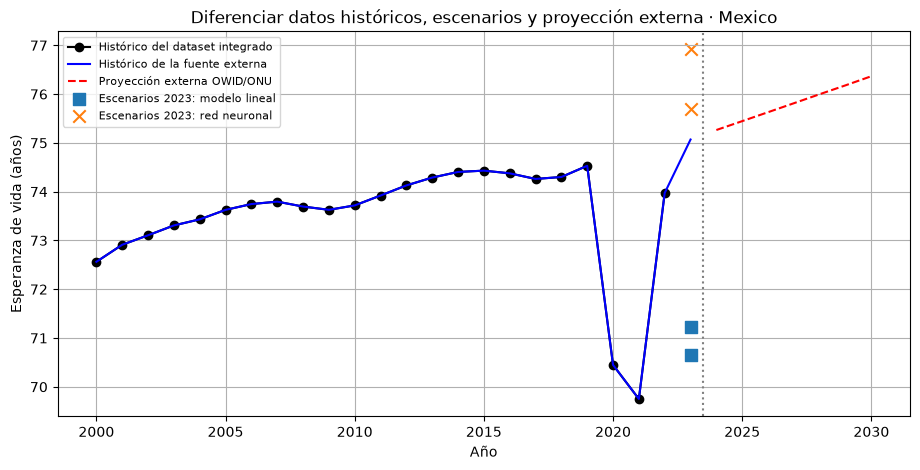

In [ ]:
historico_corto = historico_owid.loc[historico_owid["year"] >= 2000]
proyeccion_corta = proyeccion_owid.loc[proyeccion_owid["year"] <= 2030]
plt.figure(figsize=(11, 5))
plt.plot(datos_pais["year"], datos_pais[objetivo], "o-", color="black", label="Histórico del dataset integrado")
plt.plot(historico_corto["year"], historico_corto["life_expectancy_owid"], color="blue", label="Histórico de la fuente externa")
plt.plot(proyeccion_corta["year"], proyeccion_corta["life_expectancy_owid"], "--", color="red", label="Proyección externa OWID/ONU")
plt.scatter(escenarios["year"], escenarios["estimacion_lineal"], marker="s", s=65, label="Escenarios 2023: modelo lineal")
plt.scatter(escenarios["year"], escenarios["estimacion_red"], marker="x", s=80, label="Escenarios 2023: red neuronal")
plt.axvline(inicio_proyecciones - 0.5, color="gray", linestyle=":")
plt.xlabel("Año"); plt.ylabel("Esperanza de vida (años)")
plt.title(f"Diferenciar datos históricos, escenarios y proyección externa · {pais}")
plt.legend(fontsize=8); plt.show()

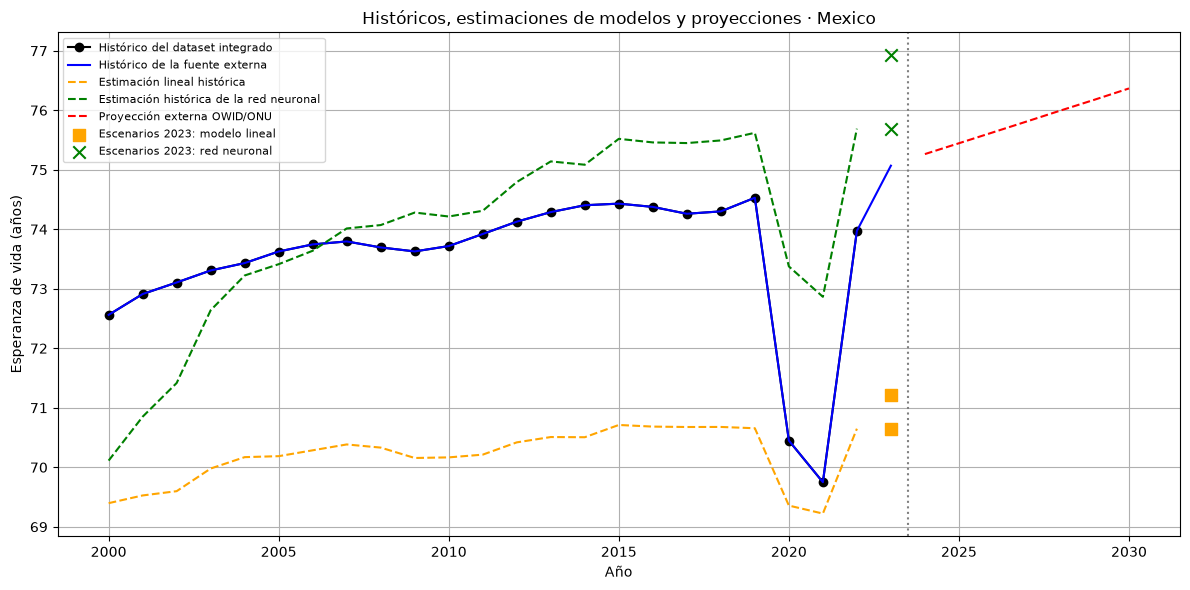

In [ ]:
historico_corto = historico_owid.loc[historico_owid["year"] >= 2000]
proyeccion_corta = proyeccion_owid.loc[proyeccion_owid["year"] <= 2030]

plt.figure(figsize=(12, 6))

# Datos históricos
plt.plot(
    datos_pais["year"], datos_pais[objetivo],
    "o-", color="black",
    label="Histórico del dataset integrado"
)

plt.plot(
    historico_corto["year"], historico_corto["life_expectancy_owid"],
    color="blue",
    label="Histórico de la fuente externa"
)

# Estimaciones históricas de los modelos
plt.plot(
    comparacion_pais["year"], comparacion_pais["estimacion_lineal"],
    "--", color="orange",
    label="Estimación lineal histórica"
)

plt.plot(
    comparacion_pais["year"], comparacion_pais["estimacion_red"],
    "--", color="green",
    label="Estimación histórica de la red neuronal"
)

# Proyecciones externas
plt.plot(
    proyeccion_corta["year"], proyeccion_corta["life_expectancy_owid"],
    "--", color="red",
    label="Proyección externa OWID/ONU"
)

# Escenarios de 2023
plt.scatter(
    escenarios["year"], escenarios["estimacion_lineal"],
    marker="s", s=65, color="orange", zorder=5,
    label="Escenarios 2023: modelo lineal"
)

plt.scatter(
    escenarios["year"], escenarios["estimacion_red"],
    marker="x", s=80, color="green", zorder=5,
    label="Escenarios 2023: red neuronal"
)

plt.axvline(
    inicio_proyecciones - 0.5,
    color="gray", linestyle=":"
)

plt.xlabel("Año")
plt.ylabel("Esperanza de vida (años)")
plt.title(f"Históricos, estimaciones de modelos y proyecciones · {pais}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### ¿Por qué sus valores quedan separados?

Porque cada modelo aprende una relación diferente:
- La regresión lineal combina las variables mediante coeficientes y una suma.
- La red neuronal puede aprender relaciones no lineales e interacciones entre variables. (Mediante una función de activación)

**Cierre de la extensión:**

Las proyecciones externas pueden servir como referencia para discutir escenarios. No son observaciones futuras ni sustituyen la evaluación de nuestros modelos. No se incorporan como objetivos de entrenamiento.